# Experiment A-06 - NN Architecture Dependence (less complex architecture)

## **🔴 Context**

- Until now, for the neural network only 2 hidden layers, a width of 32 and activation function tanh was used.
- In experiment A-05 more complex architectures were tested, yielding no improvement.
- Less complex architectures could be computationally cheaper.

---

## **🟡 Experiment Questions**

#### **Q1 - Does less complex MLP architectures perform better?**

H1 W64 and H2 W128 outperform the other architectures. They both score in different metrics however.

#### **Q2 - How computationally cheaper are less complex architectures?**

| H_ W__ | rel. H2 W32 (default) |
|------|---|
| H1 W16   | 2.0 x |
| H1 W32   | 1.2 x |
| H1 W64  | 0.57 x |
| H1 W128  | 0.2 x |

H1 W16/32 ar computationally cheaper, but H1 W64 is more expensive.

---


## **🟢 Short Result**
#### H1 W64 and H1 W128 perform similar in skill and stability, but H1 W64 is approx. 3x faster than H1 W64.


---

## **0. Setup**

In [1]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics

In [2]:
# Define experiment
EXP = "exp_A_06_arch_smaller";

## **1. Training**

In [3]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 600));

In [4]:
# Define experiment and schemes
SCHEMES = ["NLW_H1_W16", "NLW_H1_W32", "NLW_H1_W64", "NLW_H1_W128"]
LABELS = ["H1 W16", "H1 W32", "H1 W64", "H1 W128"]
COLORS = [JL_BLUE, JL_GREEN, JL_RED, JL_PURPLE];
STEPS = 100:500;

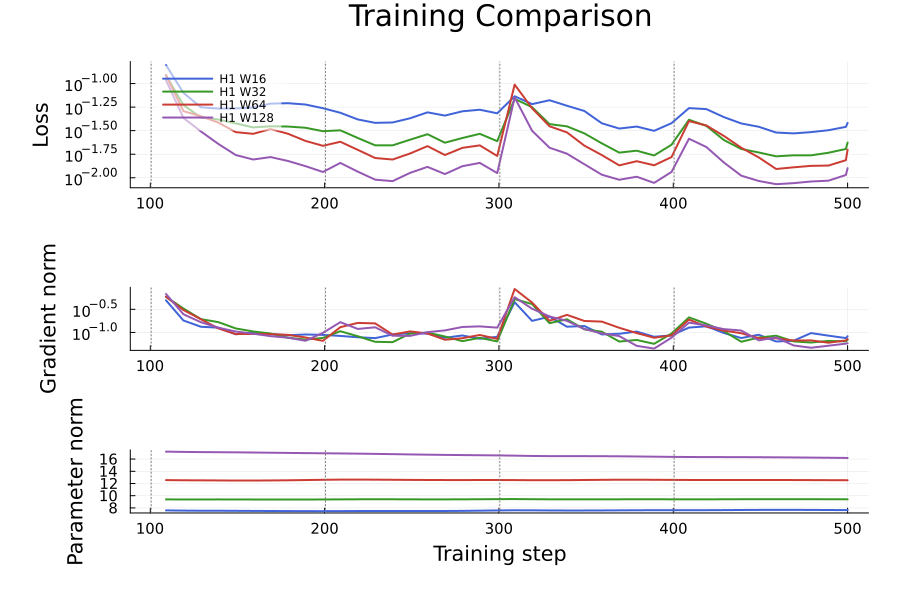

In [5]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

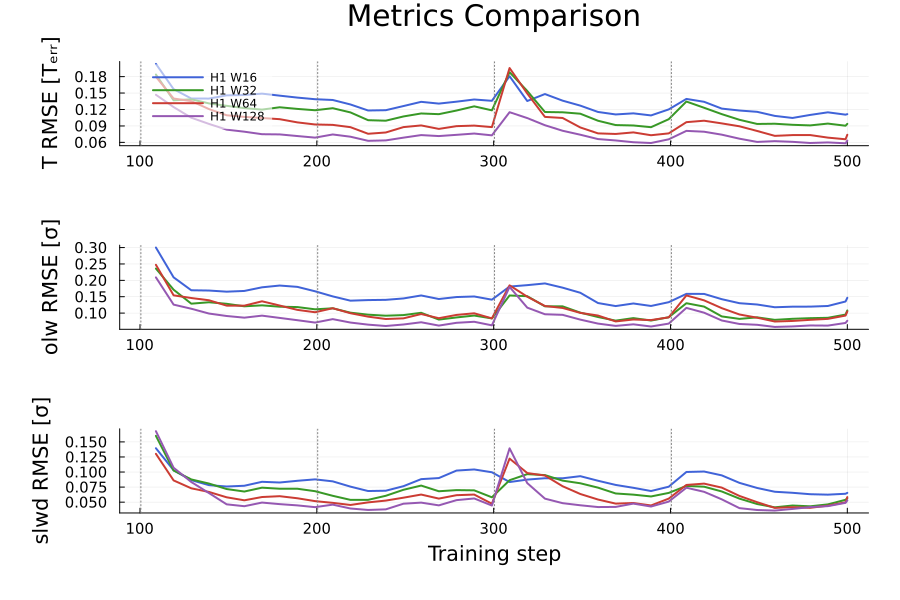

In [6]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [7]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

In [8]:
# Load NeuralLW with default arch (H2 W32) rollouts
EXP_H2W32 = "exp_A_05_arch";
skill_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_gelu_skill"]);
stab_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_gelu_stab"]);

In [9]:
# Load different architectures scheme rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "NLW_H1_W16_skill",
    "NLW_H1_W32_skill",
    "NLW_H1_W64_skill", 
    "NLW_H1_W128_skill"
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill_arch = collect_rollouts(EXP, SKILL_NAMES);
stab_arch = collect_rollouts(EXP, STAB_NAMES);

In [10]:
# Merge rollouts and define labels and colors
skill = merge(skill_H2W32, skill_arch);
stab = merge(stab_H2W32, stab_arch);

LABELS = ["H2 W32", "OBLW", "H1 W16", "H1 W32", "H1 W64", "H1 W128"]
COLORS = [:black, :grey, JL_BLUE, JL_GREEN, JL_RED, JL_PURPLE];

### 2.1. Skill (31 days)

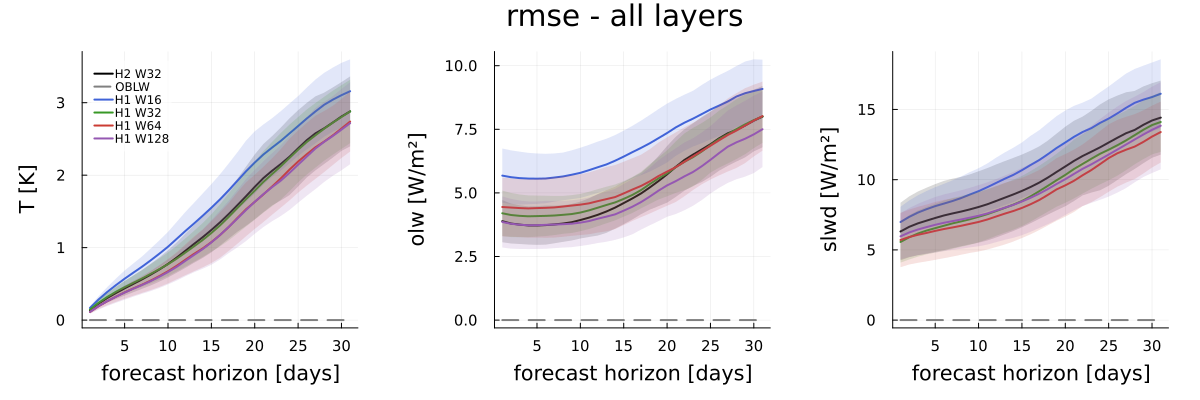

In [11]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

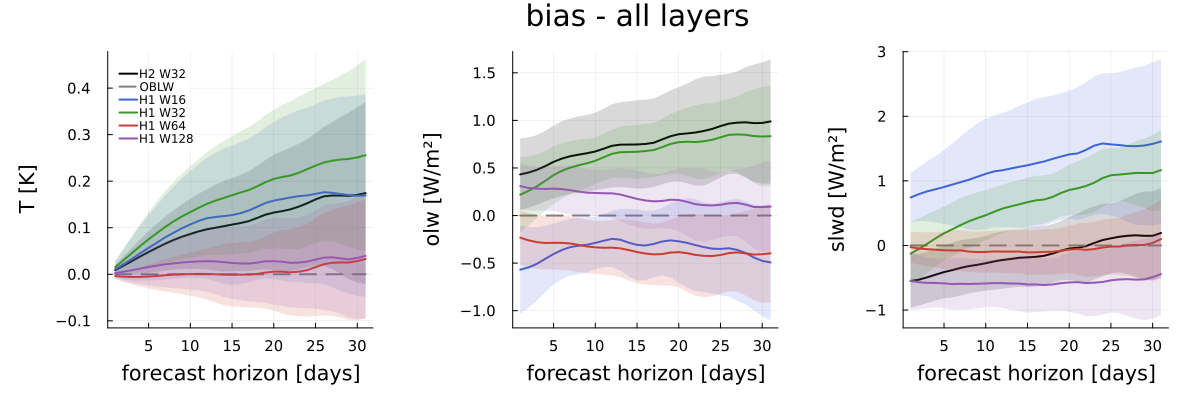

In [12]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

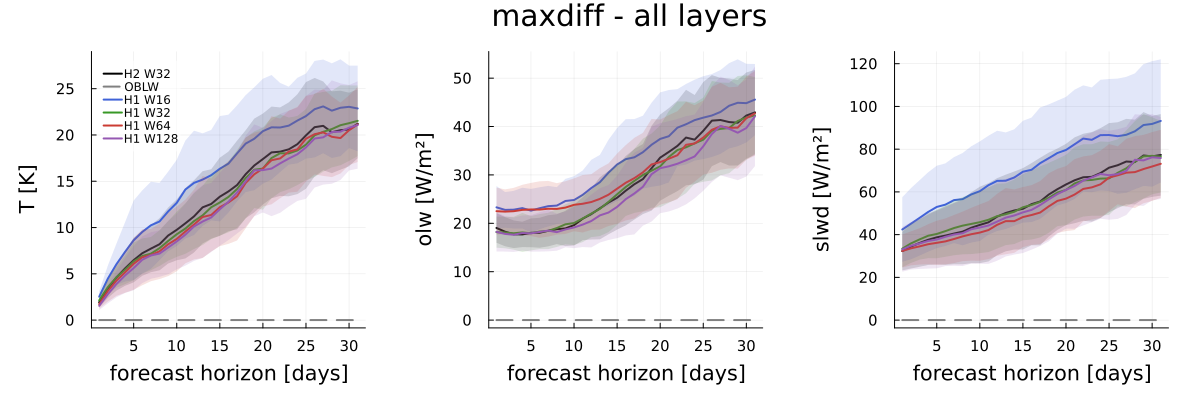

In [13]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

### 2.2. Stability (365 days)

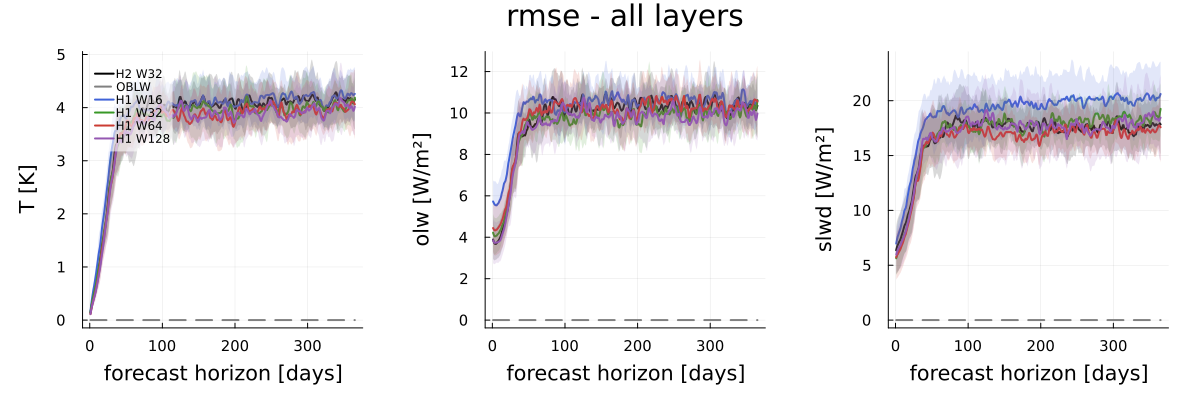

In [14]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

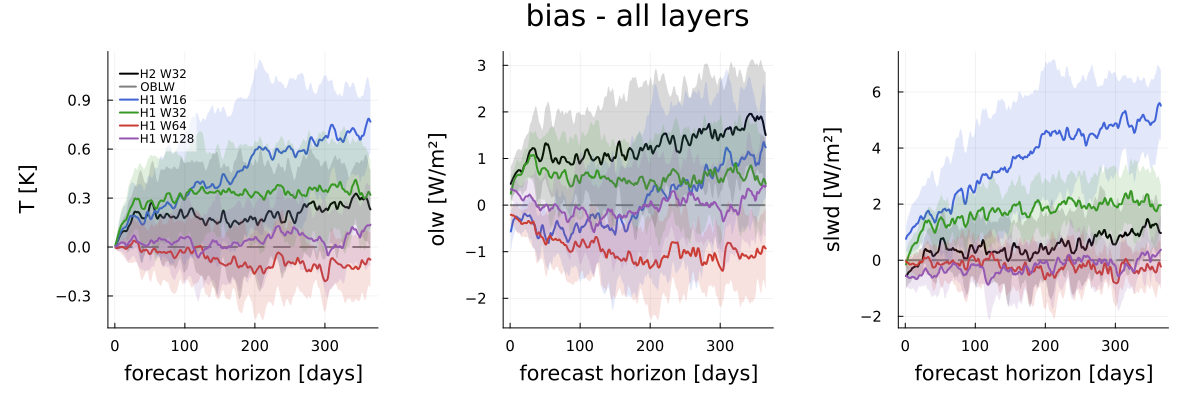

In [15]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

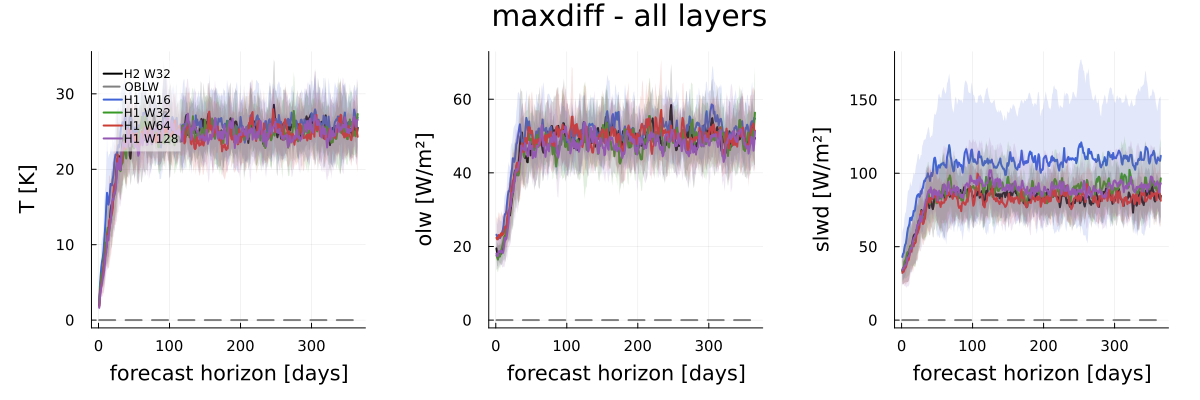

In [16]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

## **3. Benchmark**

In [17]:
# Define spectral grid for benchmark evaluation
using SpeedyWeather
SG = SpectralGrid(trunc = 31, nlayers = 8);

In [18]:
# Load schemes
schemes = merge(
    (; OBLW = build_scheme(:OBLW, SG)),
    collect_schemes("exp_A_02_NLW_outputForms", ["NLW_planck"]),
    collect_schemes(EXP, ["NLW_H1_W16", "NLW_H1_W32", "NLW_H1_W64", "NLW_H1_W128"]),
);

In [19]:
# Evaluate and print bencnhmark results
res = benchmark_scheme(schemes; spectral_grid = SG)
print_benchmark(res; baseline = :OBLW);


scheme                    ms/step   med/min     KB/step      allocs    rel.
---------------------------------------------------------------------------
OBLW                       0.6471       1.0         0.0           0    1.0×
NLW_planck                 8.7665      1.06      6187.5      101376  13.55×
NLW_H1_W16                 4.3474      1.09      4059.0       72864   6.72×
NLW_H1_W32                 7.0446      1.07      4455.0       72864  10.89×
NLW_H1_W64                15.3276      1.03      5346.0       72864  23.69×
NLW_H1_W128               43.3608      1.03      6831.0       72864  67.01×
